In [ ]:
"""
LinearRegression
MultiLinearRegression
PolinomialRegression
NonLinearRegression
LogisticRegression
"""

'\n'

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

data = pd.read_csv('./drive/MyDrive/documents/BelajarML/harga_rumah.csv')
print(data.head())

x = data.drop(columns=['harga_juta'])
y = data['harga_juta']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_linear = LinearRegression()
model_linear.fit(x_train, y_train)

result = model_linear.predict(pd.DataFrame({
    "luas_m2": [42],
    "usia_tahun": [20]
}))

f"Hasil prediksi: Rp{result[0]:0.0f} Juta"

   luas_m2  harga_juta  usia_tahun
0       36         288          25
1       40         320          22
2       45         360          20
3       50         395          18
4       55         440          15


'Hasil prediksi: Rp334 Juta'

In [ ]:
!pip install skl2onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Tentukan tipe input:
# contoh: [None, 2] None berarti batch size bisa dinamis, dan 2 berarti jumlah fitur
initial_type = [('float_input', FloatTensorType([None, 2]))]
onx = convert_sklearn(model_linear, initial_types=initial_type)

with open("model_linear.onnx", "wb") as f:
    f.write(onx.SerializeToString())

Model berhasil disimpan ke rf_iris.onnx


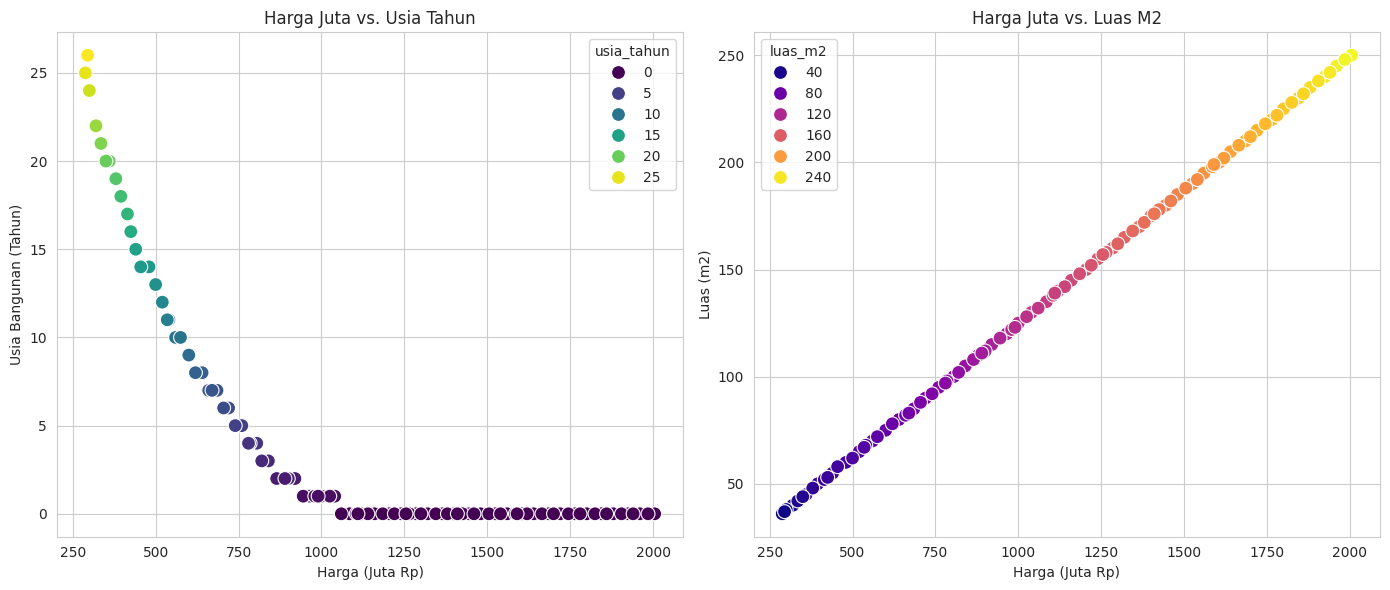

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for harga_juta vs. usia_tahun
sns.scatterplot(x='harga_juta', y='usia_tahun', data=data, ax=axes[0], hue='usia_tahun', palette='viridis', s=100)
axes[0].set_title('Harga Juta vs. Usia Tahun')
axes[0].set_xlabel('Harga (Juta Rp)')
axes[0].set_ylabel('Usia Bangunan (Tahun)')

# Scatter plot for harga_juta vs. luas_m2
sns.scatterplot(x='harga_juta', y='luas_m2', data=data, ax=axes[1], hue='luas_m2', palette='plasma', s=100)
axes[1].set_title('Harga Juta vs. Luas M2')
axes[1].set_xlabel('Harga (Juta Rp)')
axes[1].set_ylabel('Luas (m2)')

plt.tight_layout()
plt.show()

In [ ]:
"""
Parameter utama dari PolinomialRegression adalah jumlah derajatnya,
derajat 1 dan 2 untuk model yg bisa lebih general data tapi tidak tapi sulit menangkap fitur data kompleks
3 bisa untuk data kompleks tapi resiko overfit terutama jika data sedikit
"""

'\nParameter utama dari PolinomialRegression adalah jumlah derajatnya,\n'

In [ ]:
"""
DecisionTree Regression, paramter utamanya:
max_depth
minimum_sample_split
minimum_sample_leaf
max_features
"""
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

data = pd.read_csv("./drive/MyDrive/documents/BelajarML/harga_rumah_fitur_luas_lokasi.csv")
print(data.head())
x = data.drop(columns='harga_juta')
y = data['harga_juta']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_tree = DecisionTreeRegressor(max_depth=3)
model_tree.fit(x_train, y_train)

score = model_tree.score(x_test, y_test)
f"{score:2.0%}"

   luas_m2  jarak_pusat_kota_km  harga_juta
0       36                 25.0         180
1       45                 20.0         240
2       60                 15.0         380
3       72                 10.0         520
4       85                  8.0         680


'96%'